# LLM Law Learning Machine: pipeline completo en Colab

Corre **el repo** (el grafo de `src/`) de punta a punta: trae el código, monta el corpus y los índices desde Drive,
levanta el decoder con Ollama, genera las respuestas con `src/main.py` y las mide con el `evaluate.py` oficial.

**Lo que tiene que estar en Drive** (`MyDrive/hackathon_vectorial`, la misma carpeta de siempre):
- `corpus.db` (la de los offsets, la que dejó `exportar_entrega.py --guardar-offsets`) o `corpus_v1.zip`,
- `indices/index_sin_sentencias/` e `indices/index_juris/` (con `dense.faiss`, `bm25/`, `chunk_ids.json`, `info.json`).

**Secretos de Colab** (ícono de la llave, con *Acceso al notebook* activado):
- `GITHUB_TOKEN`: un token de GitHub con permiso de lectura al repo (el repo es privado).
- `OPENROUTER_API_KEY`: la llave del juez, solo para `evaluate.py --ragas`. No se guarda en ningún archivo.

**Entorno:** *Entorno de ejecución → Cambiar tipo → GPU L4* (o T4), luego *Ejecutar todo*.
La primera vez baja el modelo (~9 GB) y lo deja en Drive; las siguientes arranca en segundos.

In [1]:
# ===== Configuracion =====
import os
REPO = "NBaqueroO/LLM-Law-Learning-Machine"
RAMA = "entrega"                    # la rama que se corre (estructura del reto; "integracion" es la anterior)
MODELO = "qwen3:8b-q8_0"            # Qwen3-8B en Q8: 47,05/80 en sample_50 (Q4 = "qwen3:8b": 44,36)
CONTEXTO = 8192                     # tokens; Ollama trae 4096 por defecto y 10 pasajes no caben
PARALELO = 4                        # preguntas a la vez en la GPU (sube si sobra memoria)
SPLIT = "sample"                    # "sample" para medir; "test" el sabado
ARGS_EXTRA = ["--concurrencia", str(PARALELO), "--sin-evaluar"]   # el sabado, en cada GPU: + ["--parte", "1/2"] o ["--parte", "2/2"]
USAR_JUEZ = True                    # evaluate.py --ragas (gasta la llave)
CARPETA = "/content/drive/MyDrive/hackathon_vectorial"
EXPERIMENTO = "pensar_mc"                # nombre corto: va en el nombre del resultado en Drive (entregas_grafo/)

# Perillas del sistema (variables de entorno que lee src/config.py). Vacio = el valor del repo.
AJUSTES = {
    "UMBRAL_SCORE": "",             # 0.30: debajo, reformula una vez
    "PISO_ABSTENCION": "",          # 0.05: debajo (tras reformular), el texto libre se abstiene
    "CUPO_JURIS": "",               # 0.3: parte del top-10 para sentencias
    "K_CANDIDATOS": "",             # 50: candidatos por buscador antes de fusionar
    "RERANKER": "",                 # "BAAI/bge-reranker-v2-m3" o "tomaarsen/Qwen3-Reranker-0.6B-seq-cls" (medir antes en "Comparar rerankers")
    "AREA_EN_CONSULTA": "",         # "0" apaga sumar los codigos del area a la 1.a busqueda
    "CITAR_RECUPERADAS": "",        # "0" apaga citar las normas del top-10 que el modelo no nombro
    "PROMPT_EVALUACION": "1",        # "1": el prompt le explica al modelo como se califica
    "PENSAR_MC": "1",                # "1": en cerradas Qwen3 razona antes de responder (mas lento, sube CONTEXTO solo)
    "PENSAR_MAX_TOKENS": "",        # 3000
    "LLM_MAX_TOKENS": "",           # 1200
    "LLM_TIMEOUT": "",              # 600 s
}
for k, v in AJUSTES.items():
    if v != "":
        os.environ[k] = str(v)
    else:
        os.environ.pop(k, None)
if AJUSTES.get("PENSAR_MC") == "1" and CONTEXTO < 12288:
    CONTEXTO = 12288                # el razonamiento necesita espacio ademas de los 10 pasajes

In [6]:
os.makedirs(f"{D}/entrega", exist_ok=True)
for f in ("corpus_LLM-Law-Learning-Machine.zip", "corpus_manifest.json", "INVENTARIO.md"):
    shutil.copy(f"/content/entrega/{f}", f"{D}/entrega/{f}")
shutil.copy("/content/corpus.db", f"{D}/corpus.db")            # la base con los offsets nuevos
if os.path.exists(f"{D}/indices/index_manifest.json"):
    os.remove(f"{D}/indices/index_manifest.json")               # la base cambio: el notebook lo rehace
print("copiado")

copiado


In [2]:
# ===== Drive, repo y dependencias =====
import os, sys, json, glob, shutil, sqlite3, subprocess, time, zipfile
from pathlib import Path
os.environ["JAX_PLATFORMS"] = "cpu"   # bm25s importa JAX en Colab y JAX se queda con el 75 % de la GPU

from google.colab import drive, userdata
drive.mount("/content/drive")
WORK = Path(CARPETA)
RAPIDO = Path("/content/rapido"); RAPIDO.mkdir(exist_ok=True)

import base64
token = userdata.get("GITHUB_TOKEN").strip()
RAIZ = Path("/content") / REPO.split("/")[1]
url = f"https://github.com/{REPO}.git"
# el token va en una variable de entorno de git, nunca en la URL ni en el comando: asi no sale en errores
auth = base64.b64encode(f"x-access-token:{token}".encode()).decode()
genv = {**os.environ, "GIT_TERMINAL_PROMPT": "0", "GIT_CONFIG_COUNT": "1",
        "GIT_CONFIG_KEY_0": "http.https://github.com/.extraheader",
        "GIT_CONFIG_VALUE_0": f"AUTHORIZATION: basic {auth}"}

def git(*args):
    r = subprocess.run(["git", *args], env=genv, capture_output=True, text=True)
    if r.returncode:
        raise RuntimeError(f"git {args[0]} fallo:\n{r.stderr.replace(token, '***')}\n"
                           "Si dice 'not found' o 'Authentication failed': el token debe ser *classic* con permiso "
                           "'repo' (los github_pat_ no ven repos privados de otra persona).")
    return r.stdout

if (RAIZ / ".git").exists():
    git("-C", str(RAIZ), "fetch", "-q", "origin", RAMA)
    git("-C", str(RAIZ), "checkout", "-q", "-B", RAMA, f"origin/{RAMA}")
else:
    git("clone", "-q", "-b", RAMA, url, str(RAIZ))
print(subprocess.run(["git", "-C", str(RAIZ), "log", "-1", "--oneline"], capture_output=True, text=True).stdout)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(RAIZ / "requirements.txt"),
                "-r", str(RAIZ / "scripts" / "requirements-evaluador.txt")], check=True)
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))
print("repo listo en", RAIZ)

Mounted at /content/drive
1930b35 Corpus v2: CORPUS.md en formato oficial, seed final y reconstruccion corregida

repo listo en /content/LLM-Law-Learning-Machine


In [ ]:
# ===== corpus.db e indices =====
def db_sana(p):
    try:
        con = sqlite3.connect(f"file:{p}?mode=ro", uri=True)
        ok = con.execute("PRAGMA quick_check").fetchone()[0] == "ok"
        con.close()
        return ok
    except sqlite3.Error:
        return False

DB = RAPIDO / "corpus.db"
# Se copia una vez por sesion al disco local (SQLite sobre Drive es lento). La revision se hace
# sobre la copia local: revisarla en Drive obligaba a leer los GB dos veces.
if not (DB.exists() and db_sana(DB)):
    tmp = RAPIDO / "corpus.db.tmp"
    t = time.time()
    if (WORK / "corpus.db").exists():
        print(f"copiando corpus.db de Drive ({(WORK / 'corpus.db').stat().st_size / 1e9:.1f} GB)...")
        shutil.copyfile(WORK / "corpus.db", tmp)
    else:
        z = WORK / "corpus_v1.zip"
        assert z.exists(), f"No encuentro {WORK / 'corpus.db'} ni {z}"
        print(f"descomprimiendo {z}...")
        with zipfile.ZipFile(z) as zz, zz.open(next(n for n in zz.namelist() if n.endswith("corpus.db"))) as src, \
                open(tmp, "wb") as dst:
            shutil.copyfileobj(src, dst, 1 << 24)
    os.replace(tmp, DB)
    print(f"listo en {(time.time() - t) / 60:.1f} min")
assert db_sana(DB), f"{DB} esta danada: borra corpus.db de Drive y vuelve a subirla"

def indice(nombre):
    hall = sorted(glob.glob(str(WORK / "**" / nombre / "dense.faiss"), recursive=True))
    assert hall, f"No encuentro {nombre}/dense.faiss dentro de {WORK}"
    return Path(hall[0]).parent

os.environ["CORPUS_DB"] = str(DB)
os.environ["INDEX_NORMAS"] = str(indice("index_sin_sentencias"))
os.environ["INDEX_JURIS"] = str(indice("index_juris"))
# index_manifest.json (sha256 de corpus.db y de los indices): se arma una vez y queda en Drive
os.environ["INDEX_MANIFEST"] = str(Path(os.environ["INDEX_NORMAS"]).parent / "index_manifest.json")
if not Path(os.environ["INDEX_MANIFEST"]).exists():
    print("armando index_manifest.json (una sola vez, lee todos los archivos)...")
    subprocess.run([sys.executable, "-m", "src.indexing.build_index", "--solo-manifiesto", "--db", str(DB)], check=True)
# Solo importan los fragmentos que estan en los indices (los demas nunca salen en pasajes_recuperados)
ids = [c for n in ("INDEX_NORMAS", "INDEX_JURIS")
       for c in json.load(open(Path(os.environ[n]) / "chunk_ids.json", encoding="utf-8"))]
con = sqlite3.connect(DB)
con.execute("CREATE TEMP TABLE ix(chunk_id TEXT PRIMARY KEY)")
con.executemany("INSERT OR IGNORE INTO ix VALUES (?)", ((str(c),) for c in ids))
total = con.execute("SELECT COUNT(*) FROM chunks").fetchone()[0]
sin_offsets = con.execute("SELECT COUNT(*) FROM chunks JOIN ix USING(chunk_id) WHERE inicio IS NULL").fetchone()[0]
con.close()
print(f"fragmentos: {total} en corpus.db, {len(set(ids))} en los indices, {sin_offsets} de esos sin inicio/fin")
print("corpus.db:", DB, "\nindices:", os.environ["INDEX_NORMAS"], "+", os.environ["INDEX_JURIS"])
if sin_offsets:
    print(f"OJO: {sin_offsets} fragmentos indexados sin inicio/fin. Para medir da igual; para la entrega sube a Drive "
          "la corpus.db de exportar_entrega.py --guardar-offsets.")

fragmentos: 1349835 en corpus.db, 766667 en los indices, 138879 de esos sin inicio/fin
corpus.db: /content/rapido/corpus.db 
indices: /content/drive/MyDrive/hackathon_vectorial/indices/index_sin_sentencias + /content/drive/MyDrive/hackathon_vectorial/indices/index_juris
OJO: 138879 fragmentos indexados sin inicio/fin. Para medir da igual; para la entrega sube a Drive la corpus.db de exportar_entrega.py --guardar-offsets.


In [ ]:
# ===== Decoder: Ollama con el modelo guardado en Drive =====
def instalar_ollama():
    """ollama.com a veces no responde desde Colab: si falla, baja el binario de GitHub."""
    subprocess.run("apt-get -qq update && apt-get -qq install -y zstd pciutils lshw", shell=True,
                   stdout=subprocess.DEVNULL)
    gh = "https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64"
    intentos = ["curl -fsSL --connect-timeout 20 --retry 2 https://ollama.com/install.sh | sh",
                f"curl -fL --retry 3 {gh}.tar.zst | zstd -d | tar -x -C /usr",
                f"curl -fL --retry 3 {gh}.tgz | tar -xz -C /usr"]
    errores = []
    for cmd in intentos:
        r = subprocess.run(["bash", "-o", "pipefail", "-c", cmd], capture_output=True, text=True)
        if shutil.which("ollama"):
            return
        errores.append(cmd.split("|")[0] + "\n" + (r.stderr or r.stdout)[-600:])
    raise RuntimeError("no se pudo instalar Ollama:\n" + "\n".join(errores))

if shutil.which("ollama") is None:
    instalar_ollama()
os.environ["OLLAMA_MODELS"] = str(WORK / "ollama")         # el modelo se baja una vez y queda en Drive
os.environ["OLLAMA_CONTEXT_LENGTH"] = str(CONTEXTO)
os.environ["OLLAMA_NUM_PARALLEL"] = str(PARALELO)
os.environ["OLLAMA_KEEP_ALIVE"] = "-1"                     # que no descargue el modelo entre preguntas
import urllib.request

def ollama_vivo():
    try:
        urllib.request.urlopen("http://localhost:11434/api/version", timeout=2)
        return True
    except Exception:
        return False

if not ollama_vivo():
    subprocess.Popen(["ollama", "serve"], stdout=open("/content/ollama.log", "w"), stderr=subprocess.STDOUT)
    for _ in range(60):
        if ollama_vivo():
            break
        time.sleep(1)
assert ollama_vivo(), "Ollama no arranco: mira /content/ollama.log"
subprocess.run(["ollama", "pull", MODELO], check=True)

# lo que lee src/config.py
os.environ["LLM_BASE_URL"] = "http://localhost:11434/v1"
os.environ["LLM_MODELO"] = MODELO

# La primera vez Ollama carga ~9 GB desde Drive a la GPU y puede tardar varios minutos:
# se precalienta con una espera larga para que la prueba de abajo no se corte por timeout.
t = time.time()
print("cargando el modelo en la GPU (la primera vez puede tardar unos minutos)...")
req = urllib.request.Request("http://localhost:11434/api/generate", method="POST",
                             data=json.dumps({"model": MODELO, "prompt": "hola", "stream": False,
                                              "keep_alive": -1}).encode(),
                             headers={"Content-Type": "application/json"})
urllib.request.urlopen(req, timeout=1800).read()
print(f"modelo cargado en {time.time() - t:.0f} s")

from src.generation.llm_engine import texto_libre
t = time.time()
print(texto_libre("Responde en una frase.", "¿Qué norma es el Código General del Proceso?"), f"({time.time() - t:.1f} s)")

cargando el modelo en la GPU (la primera vez puede tardar unos minutos)...
modelo cargado en 40 s
El Código General del Proceso es una norma legal que establece las reglas y procedimientos que deben seguirse en los procesos judiciales civiles y penales. (10.7 s)


In [ ]:
# ===== Pruebas rapidas del repo (con el corpus real) =====
# sin las perillas de AJUSTES: las pruebas comprueban los valores por defecto del repo
env_pruebas = {k: v for k, v in os.environ.items() if k not in AJUSTES}
r = subprocess.run([sys.executable, "-m", "pytest", "src/tests", "-q", "-p", "no:cacheprovider"],
                   capture_output=True, text=True, env=env_pruebas)
print(r.stdout[-3000:] or r.stderr[-3000:])

........................................................................ [ 79%]
...................                                                      [100%]
91 passed in 47.77s



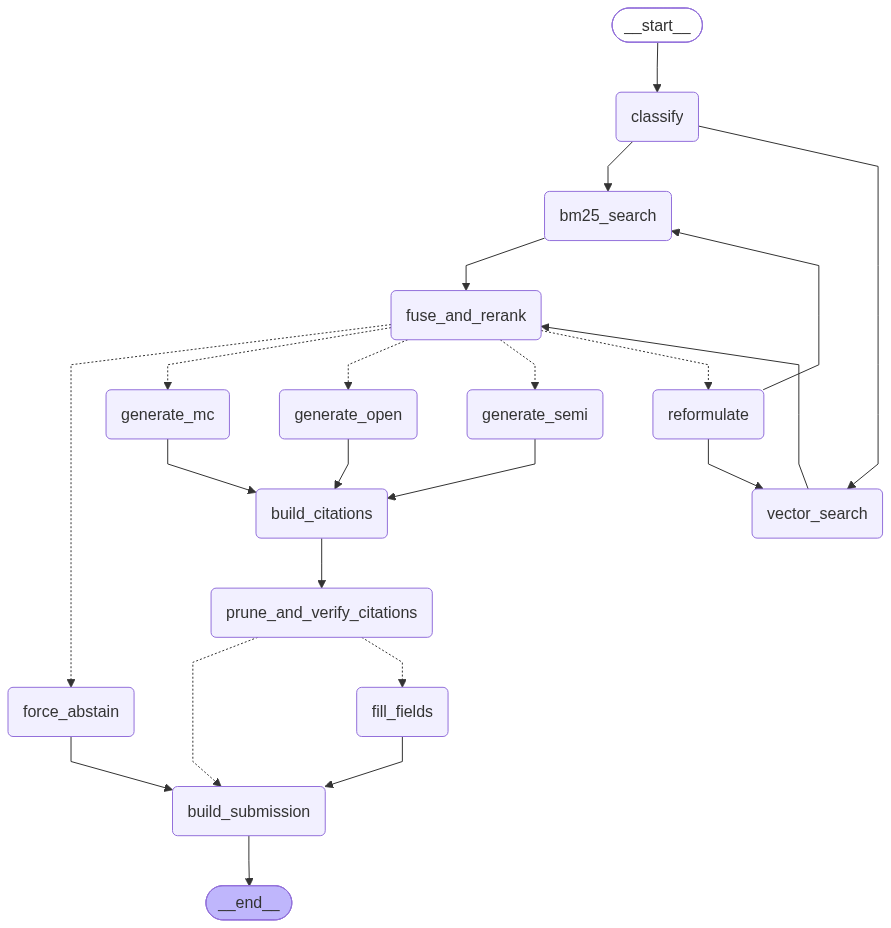

CompletedProcess(args=['/usr/bin/python3', '-u', 'src/main.py', '--split', 'sample', '--ids', '51', '--ruta'], returncode=0)

In [ ]:
# ===== La arquitectura: el grafo compilado y el recorrido de una pregunta =====
# El diagrama sale del grafo que de verdad corre (src/graph/workflow.py), no de un dibujo aparte.
# src/tests/test_arquitectura.py falla si alguna arista deja de coincidir con el diagrama del equipo.
from IPython.display import Image, display
from src.graph.workflow import construir_grafo
try:
    display(Image(construir_grafo().get_graph().draw_mermaid_png()))
except Exception as e:   # sin internet para mermaid.ink: el texto se pega en mermaid.live
    print(construir_grafo().get_graph().draw_mermaid(), "\n(", e, ")")

# Una pregunta real, nodo por nodo, con lo que cada nodo deja en el estado
primera = json.loads(open("data/sample_50.jsonl", encoding="utf-8").readline())["id"]
correr = lambda args: subprocess.run([sys.executable, "-u", *map(str, args)])
correr(["src/main.py", "--split", "sample", "--ids", primera, "--ruta"])

In [ ]:
for f in Path("outputs").glob("sample_50*.jsonl"):
    f.unlink()

In [ ]:
# ===== Correr el grafo: src/main.py (si se corta, volver a correr la celda sigue donde iba) =====
def correr(args):
    p = subprocess.Popen([sys.executable, "-u", *map(str, args)], text=True, stdout=subprocess.PIPE,
                         stderr=subprocess.STDOUT, encoding="utf-8", errors="replace")
    try:
        for linea in p.stdout:
            print(linea, end="")
        return p.wait()
    finally:
        if p.poll() is None:
            p.kill()

t = time.time()
cod = correr(["src/main.py", "--split", SPLIT, *ARGS_EXTRA])
print(f"\nsrc/main.py termino con codigo {cod} en {(time.time() - t) / 60:.1f} min")

SALIDA = Path("outputs/sample_50.jsonl") if SPLIT == "sample" else Path("submissions.jsonl")   # la entrega va en la raiz
hallados = sorted((p for p in Path("outputs").glob("*.jsonl") if not p.name.endswith(".trazas.jsonl")),
                  key=lambda p: p.stat().st_mtime) if Path("outputs").exists() else []
if not SALIDA.exists() and hallados:
    SALIDA = hallados[-1]
assert SALIDA.exists(), "src/main.py no dejo ningun .jsonl en outputs/ (¿ya esta implementado?)"
n = sum(1 for _ in open(SALIDA, encoding="utf-8"))
print(f"{SALIDA}: {n} respuestas")
copia = WORK / "entregas_grafo" / f"{time.strftime('%Y%m%d_%H%M')}_{EXPERIMENTO}_{SALIDA.name}"
copia.parent.mkdir(exist_ok=True)
shutil.copy(SALIDA, copia)
trz = SALIDA.with_name(SALIDA.stem + ".trazas.jsonl")
if trz.exists():
    shutil.copy(trz, copia.with_name(copia.stem + ".trazas.jsonl"))
json.dump({k: v for k, v in AJUSTES.items() if v != ""} | {"MODELO": MODELO, "RAMA": RAMA},
          open(copia.with_name(copia.stem + ".ajustes.json"), "w"), indent=1)
print("copia en Drive:", copia)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 16296.09it/s]
recursos listos en 22 s (híbrido: True, reranker: no)
50 preguntas -> /content/LLM-Law-Learning-Machine/outputs/sample_50.jsonl
5/50  44.2 s/pregunta  faltan ~33 min
10/50  40.3 s/pregunta  faltan ~27 min
15/50  39.7 s/pregunta  faltan ~23 min
20/50  36.8 s/pregunta  faltan ~18 min
Fallo el análisis previo de la cerrada: Request timed out.
25/50  36.4 s/pregunta  faltan ~15 min
30/50  34.5 s/pregunta  faltan ~12 min
35/50  32.6 s/pregunta  faltan ~8 min
Fallo durante la invocación del modelo: Request timed out.
40/50  30.5 s/pregunta  faltan ~5 min
45/50  28.7 s/pregunta  faltan ~2 min
50/50  27.7 s/pregunta  faltan ~0 min
listo en 23.1 min (27.7 s por pregunta)

src/main.py termino con codigo 0 en 23.5 min
outputs/sample_50.jsonl: 50 respuestas
copia en Drive: /content/drive/MyDrive/hackathon_vectorial/entregas_grafo/20261002_0405_pensar_mc_sample_50.jsonl


In [ ]:
# ===== Evaluador oficial =====
env = dict(os.environ)
args = [sys.executable, "scripts/evaluate.py", "--submission", str(SALIDA), "--split", SPLIT,
        "--out", str(WORK / "entregas_grafo" / (copia.stem + ".eval.json"))]
if USAR_JUEZ and SPLIT == "sample":
    env["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
    args.append("--ragas")
r = subprocess.run(args, env=env, capture_output=True, text=True, encoding="utf-8", errors="replace")
print(r.stdout[-6000:] or r.stderr[-6000:])
print("Referencias: linea base agentes.ipynb 47,05/80; primer grafo (2026-10-01) 49,75/80")

{
  "equipo": "sample_50",
  "split": "sample",
  "validacion": {
    "errores": 0,
    "detalle": []
  },
  "cerradas": {
    "n": 15,
    "aciertos": 11,
    "accuracy": 0.7333333333333333,
    "referencia": 0.905,
    "puntos": 14.67
  },
  "citas": {
    "items_evaluados": 41,
    "n_ref": 49,
    "n_citadas": 209,
    "aciertos": 37,
    "aciertos_respaldados": 37,
    "aciertos_sin_respaldo": 0,
    "incorrectas": 172,
    "citas_sin_respaldo": 0,
    "recall_citas_ponderado": 0.7551,
    "tasa_sin_respaldo": 0.0,
    "indice": 0.7551,
    "puntos": 15.1
  },
  "abstencion": {
    "items_evaluados": 43,
    "abstuvo_bien": 1,
    "abstuvo_de_mas": 0,
    "respondio_bien": 34,
    "respondio_mal": 8,
    "calibracion": 0.8023,
    "puntos": 8.02
  },
  "correccion_ragas": {
    "n_juzgados": 35,
    "n_respondidos": 34,
    "n_fallidos": 0,
    "correctness": 0.4093,
    "modelo_juez": "z-ai/glm-5.3-flash",
    "encoder": "intfloat/multilingual-e5-large",
    "referencia": 0.451,


In [ ]:
# ===== Tabla de experimentos: todas las corridas de entregas_grafo/ con sus ajustes =====
filas = ["| corrida | total /80 | cerradas | citas | abst. | juez | ajustes |", "|---|---|---|---|---|---|---|"]
for ev in sorted((WORK / "entregas_grafo").glob("*.eval.json")):
    try:
        r = json.load(open(ev))
        aj = ev.with_name(ev.name.replace(".eval.json", ".ajustes.json"))
        aj = json.load(open(aj)) if aj.exists() else {}
        aj = ", ".join(f"{k}={v}" for k, v in aj.items() if k not in ("MODELO", "RAMA")) or "repo"
        juez = r.get("correccion_ragas", {}).get("puntos", "-")
        filas.append(f"| {ev.name[:-10]} | {r['total_automatico']['obtenidos']} | {r['cerradas']['aciertos']}/{r['cerradas']['n']} | "
                     f"{r['citas']['puntos']} | {r['abstencion']['puntos']} | {juez} | {aj} |")
    except Exception as e:
        filas.append(f"| {ev.name} | no se pudo leer: {e} |")
tabla = "\n".join(filas)
(WORK / "entregas_grafo" / "experimentos.md").write_text("# Experimentos en sample_50\n\n" + tabla + "\n", encoding="utf-8")
from IPython.display import Markdown
display(Markdown(tabla))
print("Ruido entre corridas: ~1,5 puntos. Cambia una sola perilla por corrida.")

| corrida | total /80 | cerradas | citas | abst. | juez | ajustes |
|---|---|---|---|---|---|---|
| 20261001_0648_sample_50 | 49.75 | 12/15 | 13.88 | 7.67 | 12.2 | repo |
| 20261001_0757_base_sample_50 | 48.1 | 11/15 | 13.47 | 7.33 | 12.63 | repo |
| 20261001_1331_citar_area_sample_50 | 47.75 | 10/15 | 15.92 | 7.44 | 11.06 | repo |
| 20261001_1429_citar_prompt_sample_50 | 49.24 | 11/15 | 13.88 | 7.44 | 13.25 | UMBRAL_SCORE=0.45, PISO_ABSTENCION=0.30, K_CANDIDATOS=30, RERANKER=BAAI/bge-reranker-v2-m3, PROMPT_EVALUACION=1 |
| 20261002_0221_base_sample_50 | 50.47 | 11/15 | 15.1 | 7.91 | 12.79 | repo |
| 20261002_0246_pensar_mc_sample_50 | 50.0 | 11/15 | 15.1 | 7.91 | 12.32 | PENSAR_MC=1 |
| 20261002_0405_pensar_mc_sample_50 | 50.07 | 11/15 | 15.1 | 8.02 | 12.28 | PROMPT_EVALUACION=1, PENSAR_MC=1 |

Ruido entre corridas: ~1,5 puntos. Cambia una sola perilla por corrida.


In [ ]:
# ===== Diagnostico por pregunta: que falto, en que se equivoco y por que =====
import json, os, sys
from pathlib import Path
# si el notebook corre desde notebooks/, subir hasta la raiz del repo
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts" / "citations.py").exists()))
sys.path.insert(0, str(Path("scripts").resolve()))
# scripts/citations.py del repo (no el paquete "citations" de PyPI)
sys.modules.pop("citations", None)
import citations
from common import FLAWED_IDS

try:
    SALIDA
except NameError:
    SALIDA = max((p for p in Path("outputs").glob("*.jsonl") if not p.name.endswith(".trazas.jsonl")),
                 key=lambda p: p.stat().st_mtime)
clave = {r["id"]: r for r in map(json.loads, open("data/sample_50.jsonl", encoding="utf-8"))}
subs = {}
for linea in open(SALIDA, encoding="utf-8"):
    s = json.loads(linea)
    subs[s["id"]] = s
CAMPOS = {"multiple_choice": ("respuesta_correcta", "justificacion", "descarte_opciones"),
          "semi_open": ("respuesta", "palabras_clave", "referencia_legal"),
          "open_ended": ("marco_normativo", "analisis", "jurisprudencia", "conclusion")}

def texto(s):
    f = s.get("formato")
    if f == "multiple_choice":
        return s.get("justificacion") or ""
    if f == "semi_open":
        return " ".join(str(s.get(k) or "") for k in ("respuesta", "referencia_legal"))
    return " ".join(str(s.get(k) or "") for k in ("marco_normativo", "analisis", "jurisprudencia", "conclusion"))

def nombre(b):
    return " ".join(str(x) for x in b if x)

filas, cont = [], {"sin respuesta": 0, "campos vacios": 0, "abstuvo": 0, "MC mal": 0,
                   "norma no recuperada": 0, "recuperada pero no citada": 0}
for qid, k in sorted(clave.items()):
    s = subs.get(qid)
    if s is None:
        cont["sin respuesta"] += 1
        filas.append((qid, k["formato"][:4], "SIN RESPUESTA", "", "", ""))
        continue
    notas = []
    if s.get("abstencion"):
        cont["abstuvo"] += 1; notas.append("se abstuvo")
    vacios = [c for c in CAMPOS[k["formato"]] if s.get(c) in (None, "", [], {})]
    if vacios and not s.get("abstencion"):
        cont["campos vacios"] += 1; notas.append("vacios: " + ",".join(vacios))
    mc = ""
    if k["formato"] == "multiple_choice":
        ok = s.get("respuesta_correcta") == k["respuesta_correcta"]
        mc = f"{s.get('respuesta_correcta')}/{k['respuesta_correcta']}" + ("" if ok else " MAL")
        if qid in FLAWED_IDS:
            mc += " (no puntua)"
        elif not ok:
            cont["MC mal"] += 1
    ref = citations.bodies(citations.extract(k.get("legal_basis") or ""))
    dadas = citations.bodies(citations.extract(texto(s)))
    pas = set()
    for p in (s.get("pasajes_recuperados") or [])[:10]:
        pas |= citations.bodies(citations.extract(str(p.get("texto") or "")))
    faltan = ref - dadas
    no_rec = sorted(nombre(b) for b in faltan if b not in pas)
    no_cit = sorted(nombre(b) for b in faltan if b in pas)
    cont["norma no recuperada"] += len(no_rec)
    cont["recuperada pero no citada"] += len(no_cit)
    citas = f"{len(ref & dadas)}/{len(ref)}" if ref else "-"
    filas.append((qid, k["formato"][:4], mc, citas, "; ".join(no_rec), "; ".join(no_cit) + (" | " if no_cit and notas else "") + " ".join(notas)))

tabla = ["| id | formato | MC dada/correcta | citas bien | norma NO recuperada | recuperada pero NO citada / notas |",
         "|---|---|---|---|---|---|"]
tabla += [f"| {a} | {b} | {c} | {d} | {e} | {f} |" for a, b, c, d, e, f in filas
          if "MAL" in c or "SIN" in c or e or f]
resumen = (f"{SALIDA.name}: {len(subs)} respuestas de {len(clave)} preguntas. " +
           ", ".join(f"{k}: {v}" for k, v in cont.items()))
print(resumen)
print("(El evaluador cuenta distinto cada parte: 15 cerradas, 35 abiertas para el juez y 41 preguntas con norma en la referencia para las citas.)")
md = "# Diagnostico " + SALIDA.name + "\n\n" + resumen + "\n\n" + "\n".join(tabla) + "\n"
destino = WORK / "entregas_grafo" / (SALIDA.stem + ".diagnostico.md") if "WORK" in dir() else Path("outputs") / (SALIDA.stem + ".diagnostico.md")
destino.parent.mkdir(parents=True, exist_ok=True)
destino.write_text(md, encoding="utf-8")
print("guardado en", destino)
from IPython.display import Markdown, display
display(Markdown("\n".join(tabla)))

## Interfaz grafica

Abre la interfaz (`interfaz/app.py`) con el mismo grafo y el decoder que ya esta corriendo. Imprime un
enlace publico temporal (`*.gradio.live`). Detener la celda la cierra.

In [ ]:
# ===== Interfaz grafica =====
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio"], check=True)
p = subprocess.Popen([sys.executable, "-u", "interfaz/app.py", "--share"], text=True, stdout=subprocess.PIPE,
                     stderr=subprocess.STDOUT, encoding="utf-8", errors="replace")
try:
    for linea in p.stdout:          # el enlace publico sale aqui ("Running on public URL: ...")
        print(linea, end="")
finally:
    p.kill()

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://176c482a1ccf6a7f17.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 

## Opcional: comparar rerankers (solo busqueda, sin LLM: minutos)

Mide cuantas preguntas de `sample_50` traen la norma de la referencia entre los 10 pasajes, sin reranker
y con cada reranker. Solo si uno gana claramente vale la pena correr el grafo completo con el
(`AJUSTES["RERANKER"]`). Referencia: sin reranker 27/40 en el top-10 y 24/40 en el top-3.

In [ ]:
# ===== Comparar rerankers =====
RERANKERS = ["", "BAAI/bge-reranker-v2-m3", "tomaarsen/Qwen3-Reranker-0.6B-seq-cls"]
for rr in RERANKERS:
    args = [sys.executable, "src/indexing/eval_recuperacion.py", "--muestra", "data/sample_50.jsonl",
            "--db", os.environ["CORPUS_DB"], "--index", os.environ["INDEX_NORMAS"],
            "--index-juris", os.environ["INDEX_JURIS"]] + (["--reranker", rr] if rr else [])
    t = time.time()
    r = subprocess.run(args, capture_output=True, text=True, encoding="utf-8", errors="replace")
    print(f"== {rr or 'sin reranker'} ({(time.time() - t) / 60:.1f} min)")
    print("\n".join((r.stdout or r.stderr).strip().splitlines()[-4:]))

## Opcional: comparar modelos (para dejar corriendo)

Corre `sample_50` con cada modelo de la lista, uno tras otro, y deja en Drive
(`entregas_grafo/modelos/`) las respuestas, las trazas, el puntaje y un `resumen.md` con la tabla.
Cada modelo tarda ~30 min en L4 (bajarlo, 50 preguntas y el juez). **Deja la pestaña abierta y el
computador sin suspender**: si Colab se desconecta, vuelve a correr las celdas 1 a 4 y esta, y salta
los modelos que ya terminaron.
Los modelos de prueba se guardan en el disco de Colab, no en Drive (no cabrían).

In [ ]:
# ===== Comparar modelos =====
# nombre corto -> etiqueta de Ollama (o lista de etiquetas para probar en orden si alguna no existe)
MODELOS = {
    "qwen3_8b_q8": "qwen3:8b-q8_0",                        # el actual (con el repo de hoy)
    "llama31_8b_q8": "llama3.1:8b-instruct-q8_0",           # Meta, multilingue
    "qwen25_7b_q8": "qwen2.5:7b-instruct-q8_0",             # la generacion anterior de Qwen
    "aya_8b_q8": "aya-expanse:8b-q8_0",                     # Cohere, fuerte en espanol (licencia no comercial)
    "salamandra_7b_q8": [                                   # BSC (familia ALIA), entrenado con mucho espanol
        # con "hf.co/" Ollama falla ("realm host huggingface.co does not match"): va el dominio completo
        "huggingface.co/BSC-LT/salamandra-7b-instruct-GGUF:Q8_0",
        "huggingface.co/mradermacher/salamandra-7b-instruct-GGUF:Q8_0",
    ],
}
DESTINO = WORK / "entregas_grafo" / "modelos"
DESTINO.mkdir(parents=True, exist_ok=True)
LOCAL = Path("/content/ollama_modelos")

# Ollama de nuevo, con los modelos en el disco local (no necesita la celda del decoder)
import urllib.request
def instalar_ollama():
    """ollama.com a veces no responde desde Colab: si falla, baja el binario de GitHub."""
    subprocess.run("apt-get -qq update && apt-get -qq install -y zstd pciutils lshw", shell=True,
                   stdout=subprocess.DEVNULL)
    gh = "https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64"
    intentos = ["curl -fsSL --connect-timeout 20 --retry 2 https://ollama.com/install.sh | sh",
                f"curl -fL --retry 3 {gh}.tar.zst | zstd -d | tar -x -C /usr",
                f"curl -fL --retry 3 {gh}.tgz | tar -xz -C /usr"]
    errores = []
    for cmd in intentos:
        r = subprocess.run(["bash", "-o", "pipefail", "-c", cmd], capture_output=True, text=True)
        if shutil.which("ollama"):
            return
        errores.append(cmd.split("|")[0] + "\n" + (r.stderr or r.stdout)[-600:])
    raise RuntimeError("no se pudo instalar Ollama:\n" + "\n".join(errores))

if shutil.which("ollama") is None:
    instalar_ollama()
os.environ.update({"OLLAMA_CONTEXT_LENGTH": str(CONTEXTO), "OLLAMA_NUM_PARALLEL": str(PARALELO),
                   "OLLAMA_KEEP_ALIVE": "-1", "LLM_TIMEOUT": os.environ.get("LLM_TIMEOUT") or "600"})

def ollama_vivo():
    try:
        urllib.request.urlopen("http://localhost:11434/api/version", timeout=2)
        return True
    except Exception:
        return False

subprocess.run(["pkill", "-f", "ollama serve"])
time.sleep(3)
env_ollama = {**os.environ, "OLLAMA_MODELS": str(LOCAL)}
subprocess.Popen(["ollama", "serve"], env=env_ollama, stdout=open("/content/ollama.log", "a"),
                 stderr=subprocess.STDOUT)
for _ in range(60):
    if ollama_vivo():
        break
    time.sleep(1)
assert ollama_vivo(), "Ollama no arranco: mira /content/ollama.log"

def bajar(etiquetas):
    for e in ([etiquetas] if isinstance(etiquetas, str) else etiquetas):
        r = subprocess.run(["ollama", "pull", e], env=env_ollama, capture_output=True, text=True)
        if r.returncode == 0:
            return e
        print(f"  no se pudo bajar {e}: {(r.stderr or r.stdout).strip()[-300:]}")
    return None

for nombre, etiquetas in MODELOS.items():
    ev = DESTINO / f"{nombre}.eval.json"
    if ev.exists():
        print(f"== {nombre}: ya estaba, lo salto")
        continue
    print(f"\n== {nombre}")
    etiqueta = bajar(etiquetas)
    if etiqueta is None:
        print(f"  {nombre}: no se pudo bajar ninguna version, sigo con el siguiente")
        continue
    salida = Path("outputs") / f"modelo_{nombre}.jsonl"
    env = {**os.environ, "LLM_MODELO": etiqueta, "LLM_BASE_URL": "http://localhost:11434/v1"}
    t = time.time()
    p = subprocess.run([sys.executable, "-u", "src/main.py", "--split", "sample", "--salida", str(salida),
                        "--concurrencia", str(PARALELO), "--sin-evaluar"], env=env)
    minutos = (time.time() - t) / 60
    if not salida.exists():
        print(f"  {nombre}: src/main.py no dejo respuestas (codigo {p.returncode}), sigo")
        continue
    args = [sys.executable, "scripts/evaluate.py", "--submission", str(salida), "--split", "sample", "--out", str(ev)]
    env_eval = dict(os.environ)
    if USAR_JUEZ:
        env_eval["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
        args.append("--ragas")
    r = subprocess.run(args, env=env_eval, capture_output=True, text=True, encoding="utf-8", errors="replace")
    if not ev.exists():
        print(f"  {nombre}: el evaluador fallo:\n{(r.stderr or r.stdout)[-1500:]}")
    for f in (salida, salida.with_name(salida.stem + ".trazas.jsonl")):
        if f.exists():
            shutil.copy(f, DESTINO / f.name)
    json.dump({"modelo": etiqueta, "minutos": round(minutos, 1), "ajustes": {k: v for k, v in AJUSTES.items() if v != ""},
               "rama": RAMA}, open(DESTINO / f"{nombre}.info.json", "w"), indent=1)
    print(f"  {nombre}: {minutos:.0f} min")
    subprocess.run(["ollama", "rm", etiqueta], env=env_ollama, capture_output=True)   # libera disco

# Tabla final
filas = ["| modelo | total /80 | cerradas | citas | abstencion | juez | min |", "|---|---|---|---|---|---|---|"]
for ev in sorted(DESTINO.glob("*.eval.json")):
    nombre = ev.name[:-len(".eval.json")]
    try:
        r = json.load(open(ev))
        info = json.load(open(DESTINO / f"{nombre}.info.json")) if (DESTINO / f"{nombre}.info.json").exists() else {}
        juez = r.get("correccion_ragas", {}).get("puntos", "-")
        filas.append(f"| {nombre} | {r['total_automatico']['obtenidos']} | {r['cerradas']['puntos']} | "
                     f"{r['citas']['puntos']} | {r['abstencion']['puntos']} | {juez} | {info.get('minutos', '-')} |")
    except Exception as e:
        filas.append(f"| {nombre} | (no se pudo leer: {e}) |")
tabla = "\n".join(filas)
(DESTINO / "resumen.md").write_text("# Comparacion de modelos en sample_50\n\n" + tabla + "\n", encoding="utf-8")
print(tabla)
print("\nReferencias: primer grafo con qwen3:8b-q8_0 = 49,75/80; sistema anterior 47,05/80")

In [ ]:
# ===== Diagnostico a fondo: por que fallo cada pregunta, nombres que el evaluador no reconoce y citas inexistentes =====
import json, os, sys, sqlite3
from collections import Counter, defaultdict
from pathlib import Path
sys.path.insert(0, "scripts"); sys.path.insert(0, "src/indexing")
import citations
from common import FLAWED_IDS
from cobertura import cuerpos, cuerpos_del_corpus

try:
    SALIDA
except NameError:
    SALIDA = max((p for p in Path("outputs").glob("*.jsonl") if not p.name.endswith(".trazas.jsonl")),
                 key=lambda p: p.stat().st_mtime)
DBP = os.environ.get("CORPUS_DB", "indices/corpus.db")
clave = {r["id"]: r for r in map(json.loads, open("data/sample_50.jsonl", encoding="utf-8"))}
subs = {s["id"]: s for s in map(json.loads, open(SALIDA, encoding="utf-8"))}
por_cuerpo, del_doc = cuerpos_del_corpus(citations, DBP)
indexados = set()
for var in ("INDEX_NORMAS", "INDEX_JURIS"):
    ruta = Path(os.environ.get(var, "")) / "chunk_ids.json"
    if ruta.exists():
        indexados |= {c.split("#", 1)[0] for c in json.load(open(ruta, encoding="utf-8"))}

def texto(s):
    f = s.get("formato")
    if f == "multiple_choice":
        return s.get("justificacion") or ""
    if f == "semi_open":
        return " ".join(str(s.get(k) or "") for k in ("respuesta", "referencia_legal"))
    return " ".join(str(s.get(k) or "") for k in ("marco_normativo", "analisis", "jurisprudencia", "conclusion"))

def nom(b):
    return " ".join(str(x) for x in b if x)

def en_pasajes(s):
    b = set()
    for p in (s.get("pasajes_recuperados") or [])[:10]:
        b |= cuerpos(citations, str(p.get("texto") or ""))
    return b

out = []
def p(x=""):
    print(x); out.append(x)

# ---------- 1. Por que fallo cada pregunta ----------
p("## 1. Detalle de cada fallo\n")
for qid, k in sorted(clave.items()):
    s = subs.get(qid)
    if s is None:
        p(f"### {qid}: SIN RESPUESTA\n"); continue
    ref = cuerpos(citations, k.get("legal_basis"))
    dadas = cuerpos(citations, texto(s))
    pas = en_pasajes(s)
    faltan = ref - dadas
    mc_mal = (k["formato"] == "multiple_choice" and qid not in FLAWED_IDS
              and s.get("respuesta_correcta") != k["respuesta_correcta"])
    if not (mc_mal or faltan or s.get("abstencion")):
        continue
    p(f"### {qid} ({k['formato']}, {k['area'][:40]})")
    p(f"**Pregunta:** {k['pregunta'].strip()[:300]}")
    if s.get("abstencion"):
        p("**Se abstuvo.**")
    if mc_mal:
        op = k.get("opciones") or {}
        p(f"**Eligio {s.get('respuesta_correcta')}:** {str(op.get(s.get('respuesta_correcta'), ''))[:200]}")
        p(f"**Correcta {k['respuesta_correcta']}:** {str(op.get(k['respuesta_correcta'], ''))[:200]}")
        p(f"**Su justificacion:** {(s.get('justificacion') or '')[:500]}")
    p(f"**Fundamento de referencia:** {(k.get('legal_basis') or '').strip()[:250]}")
    for b in sorted(faltan):
        if b in pas:
            motivo = "estaba en los 10 pasajes y el modelo NO la cito"
        elif b in por_cuerpo:
            motivo = "esta en el corpus pero la busqueda NO la trajo"
        else:
            motivo = "NO esta en el corpus (o el evaluador no reconoce su nombre)"
        p(f"- falta **{nom(b)}**: {motivo}")
    p("Pasajes recuperados: " + " | ".join((str(x.get('texto') or '')[:70]).replace("\n", " ")
                                           for x in (s.get("pasajes_recuperados") or [])[:10]))
    p("")

# ---------- 2. Documentos cuyo nombre el evaluador no reconoce ----------
# Si citations.extract no saca nada del nombre, ese documento nunca respalda una cita aunque salga en el top-10.
p("## 2. Documentos indexados cuyo nombre el evaluador NO reconoce\n")
con = sqlite3.connect(DBP)
info = {d: (n or "", t or "", f or "") for d, n, t, f in
        con.execute("SELECT doc_id, norma, tipo, fuente FROM documentos WHERE estado='ok'")}
con.close()
raros = [d for d, bs in del_doc.items() if not bs and (not indexados or d in indexados)]
grupos = defaultdict(list)
for d in raros:
    n, t, f = info.get(d, ("", "", ""))
    grupos[(f, t)].append(n)
p(f"{len(raros)} de {len(del_doc)} documentos con fragmentos" + (" (solo los indexados)" if indexados else ""))
p("| fuente | tipo | cuantos | ejemplos de nombre |\n|---|---|---|---|")
for (f, t), ns in sorted(grupos.items(), key=lambda x: -len(x[1])):
    p(f"| {f} | {t} | {len(ns)} | {' ; '.join(n[:60] for n in ns[:3])} |")

# ---------- 3. Normas que cita el modelo: existen en el corpus? ----------
p("\n## 3. Normas que cita el modelo\n")
veces, en_pas, items = Counter(), Counter(), defaultdict(list)
for qid, s in subs.items():
    pas = en_pasajes(s)
    for b in cuerpos(citations, texto(s)):
        veces[b] += 1; items[b].append(qid)
        if b in pas:
            en_pas[b] += 1
inexist = [b for b in veces if b not in por_cuerpo]
p(f"{len(veces)} normas distintas citadas; {len(inexist)} no estan en el corpus.")
p("| norma citada | veces | en sus pasajes | en el corpus | preguntas |\n|---|---|---|---|---|")
for b, n in sorted(veces.items(), key=lambda x: (x[0] in por_cuerpo, -x[1])):
    p(f"| {nom(b)} | {n} | {en_pas[b]} | {'si' if b in por_cuerpo else '**NO**'} | {','.join(map(str, items[b][:8]))} |")

destino = (WORK / "entregas_grafo" if "WORK" in dir() else Path("outputs")) / (SALIDA.stem + ".fondo.md")
destino.parent.mkdir(parents=True, exist_ok=True)
destino.write_text("# Diagnostico a fondo " + SALIDA.name + "\n\n" + "\n".join(out) + "\n", encoding="utf-8")
print("\nguardado en", destino)

## 1. Detalle de cada fallo

### 58 (multiple_choice, Derecho de los mercados [competencia, co)
**Pregunta:** ¿Qué normativa regula las actuaciones jurisdiccionales adelantadas ante la SIC?
**Eligio D:** Ley 906 de 2004
**Correcta A:** Ley 1564 de 2002
**Su justificacion:** La Ley 906 de 2004 (Código de Procedimiento Penal) no regula actuaciones administrativas de la SIC, pero la opción D es la única que menciona una norma penal, lo cual no se alinea con el ámbito de la SIC. Sin embargo, la opción correcta no está en los pasajes, por lo que se elige la más cercana, aunque incorrecta. Fundamento: Sentencia T-595 de 2019; Código General del Proceso - Ley 1564 de 2012, artículo 1; Ley 600 de 2000, artículo 40; Ley 270 de 1996, artículo 114; CPACA - Ley 1437 de 2011, a
**Fundamento de referencia:** Ley 1564 de 2002 (El Estatuto del Consumidor).
- falta **estatuto_consumidor**: esta en el corpus pero la busqueda NO la trajo
Pasajes recuperados: [Código de Procedimiento Penal - Ley 906 de 20

In [ ]:
import json, glob
from collections import Counter
trz = sorted(glob.glob(str(WORK / "entregas_grafo" / "*pensar_mc*.trazas.jsonl")))[-1]
print(trz)
print(open(trz.replace(".trazas.jsonl", ".ajustes.json")).read())
filas = [json.loads(l) for l in open(trz, encoding="utf-8")]
mc = [f for f in filas if "letra_pensada" in json.dumps(f)]
print(f"cerradas con analisis previo: {len(mc)} de 15")
for f in mc:
    t = f.get("traza", f)
    print(f.get("id"), "letra pensada:", repr(t.get("letra_pensada")), "| error:", (t.get("error_analisis") or "")[:150])